# **Prototype #02**
---

- The present notebook aims to continue the work started in `moe_nn_prototype_01.ipynb`.

- In particular, the following ailm to be explored:
    
    - The use of data from un updated expert file: `predictions_experts.csv`

    - `gating_features = ["Wind_Norm"]`


# 1. Training  gating network

In [14]:
# ---------------------------------------------------
# Paths management
# ---------------------------------------------------
import os

# Project path
PROJECT_PATH = os.path.dirname(os.path.dirname(os.getcwd()))

if os.path.exists(PROJECT_PATH):
    print(f"PROJECT_PATH = {PROJECT_PATH}")
else:
    print(f"WARNING! PROJECT_PATH not found! = {PROJECT_PATH}")
    
# Data path
DATA_PATH = PROJECT_PATH + "/Data"
if os.path.exists(DATA_PATH):
    print(f"DATA_PATH = {DATA_PATH}")
else:
    print(f"WARNING! DATA_PATH not found! = {DATA_PATH}")

OUTPUT_DIR = DATA_PATH

# ---------------------------------------------------
# Used paths
# ---------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

PROJECT_PATH = /home/mambo/Documents/Aggregation-of-experts-for-day-ahead-time-series-forecasting
DATA_PATH = /home/mambo/Documents/Aggregation-of-experts-for-day-ahead-time-series-forecasting/Data


In [15]:
# ---------------------------------------------------
# Load dataset
# ---------------------------------------------------
df_merged = pd.read_csv(DATA_PATH + "/experts_and_features_for_moe_nn.csv")

# 1. Convert to datetime (Crucial for time-based filtering)
df_merged['Date_Heure'] = pd.to_datetime(df_merged['Date_Heure'], errors='coerce')

# 2. Define how many months you want to retrieve
months_to_keep = 6 # Change this to 6 or 9 as needed

# 3. Calculate the cutoff date based on the latest date in the dataset
latest_date = df_merged['Date_Heure'].max()
cutoff_date = latest_date - pd.DateOffset(months=months_to_keep)

# 4. Filter the dataframe
df_recent = df_merged[df_merged['Date_Heure'] >= cutoff_date]

# Note: Using single quotes inside the f-string prevents syntax errors
print(f"Start date: {df_recent['Date_Heure'].min()}")
print(f"Stop date: {df_recent['Date_Heure'].max()}")
print(f"Samples : {len(df_recent)}")

df_recent.head()

Start date: 2025-05-23 23:00:00
Stop date: 2025-11-23 23:00:00
Samples : 4417


,Unnamed: 0,Date_Heure,y_true,ridge,randomforest,lgbm,Wind_Norm,Wind_Norm_Cubes,wind_cv_3h,Wind_Dir_Meteo_sin,Wind_Dir_Meteo_cos,Air_density,Hour_sin,Hour_cos,Month_sin,Month_cos
5591,5591,2025-05-23 23:00:00,1195.78,1069.538628,1154.031431,1133.145850,10.002179,1000.653964,0.030362,-0.687989,-0.725721,1.240147,-0.258819,0.965926,0.5,-0.866025
5592,5592,2025-05-24 00:00:00,1228.28,1247.306270,1211.029086,1201.168144,10.596422,1189.810257,0.031340,-0.731635,-0.681696,1.239855,0.000000,1.000000,0.5,-0.866025
5593,5593,2025-05-24 01:00:00,1329.32,1435.627250,1442.397355,1452.098201,11.187292,1400.151219,0.055926,-0.733752,-0.679418,1.239166,0.258819,0.965926,0.5,-0.866025
5594,5594,2025-05-24 02:00:00,1513.56,1550.342322,1697.501406,1636.880578,11.469407,1508.769508,0.040192,-0.716169,-0.697927,1.237871,0.500000,0.866025,0.5,-0.866025
5595,5595,2025-05-24 03:00:00,1694.37,1588.487877,1755.708430,1717.783878,11.513317,1526.164478,0.015533,-0.666617,-0.745400,1.236819,0.707107,0.707107,0.5,-0.866025


In [16]:
import torch

# ---------------------------------------------------
# Data split
# ---------------------------------------------------
n = len(df_recent)

train_end = int(0.7 * n)   # 4900 (70%)
val_end   = int(0.85 * n)  # 5950 (15%)

train_df = df_recent.iloc[:train_end]
val_df   = df_recent.iloc[train_end:val_end]
test_df  = df_recent.iloc[val_end:]

#   [--------- TRAIN --------][--- VAL ---][--- TEST ---]
#   0                     4900         5950          7000


"""
gating_features = [
    "Wind_Norm",
    "Wind_Norm_Cubes",
    "wind_cv_3h",
    "Wind_Dir_Meteo_sin",
    "Wind_Dir_Meteo_cos",
    "Air_density",
    "Hour_sin",
    "Hour_cos",
    "Month_sin",
    "Month_cos"
]"""


expert_features = [
    "ridge",
    "randomforest",
    "lgbm"]

gating_features = ["Wind_Norm"]

# Features
X_train = train_df[gating_features]
X_val = val_df[gating_features]
X_test  = test_df[gating_features]

# Experts
E_train = train_df[expert_features]
E_val = val_df[expert_features]
E_test  = test_df[expert_features]

# True energy production
y_train = train_df["y_true"]
y_val = val_df["y_true"]
y_test  = test_df["y_true"]

# ---------------------------------------------------
# Normalization (on training features ONLY)
# ---------------------------------------------------
"""Gating_features = [
    "Wind_Norm",
    "Wind_Norm_Cubes",
    "wind_cv_3h",
    "Wind_Dir_Meteo_sin",
    "Wind_Dir_Meteo_cos",
    "Air_density",
    "Hour_sin",
    "Hour_cos",
    "Month_sin",
    "Month_cos"
]
        TRAIN         VALIDATION        TEST
          ↓               ↓              ↓
      fit scaler      transform       transform
          ↓               ↓              ↓
      mean/std       same mean/std   same mean/std
"""

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# We learn statistics (mean/std) on training data
X_train_scaled = scaler.fit_transform(X_train)

# These statistics are applied then to validation and test datasets
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# ---------------------------------------------------
# Convert into PyTorch tensors
# ---------------------------------------------------
# Features
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# Experts
E_train_t = torch.tensor(E_train.to_numpy(), dtype=torch.float32)
E_val_t = torch.tensor(E_val.to_numpy(), dtype=torch.float32)
E_test_t = torch.tensor(E_test.to_numpy(), dtype=torch.float32)

# True energy production
y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_val_t = torch.tensor(y_val.to_numpy(), dtype=torch.float32)
y_test_t = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

In [17]:
print(X_train.shape)
E_val.head()
print(E_train.to_numpy()[:5,:])
print(type(E_train.to_numpy()[:5,:]))

(3091, 1)
[[1069.5386284  1154.03143076 1133.1458496 ]
 [1247.30626991 1211.02908603 1201.16814381]
 [1435.62725044 1442.39735521 1452.09820091]
 [1550.3423216  1697.50140603 1636.88057848]
 [1588.4878772  1755.70842965 1717.78387751]]
<class 'numpy.ndarray'>


In [18]:
import torch.nn as nn
import torch.optim as optim

class MoeGatingNetwork(nn.Module):
    def __init__(self, input_dim: int, n_experts: int = 3):
        super().__init__()

        self.gate = nn.Sequential(
            nn.Linear(input_dim, 3),
            nn.Tanh(),
            nn.Linear(3, n_experts)
        )

    def forward(self, x, expert_preds):
        # Inference
        logits = self.gate(x)                 # (batch, 3)

        # Softmax
        weights = torch.softmax(logits, dim=1)

        # Prediction
        y_hat = torch.sum(weights * expert_preds, dim=1, keepdim=True)

        return y_hat, weights

In [19]:
# ---------------------------------------------------
# MODEL
# ---------------------------------------------------
model = MoeGatingNetwork(input_dim=X_train_t.shape[1], n_experts=3)

# ---------------------------------------------------
# LOSS
# ---------------------------------------------------
criterion = nn.MSELoss()
history_train_loss = []
history_val_loss = []

# ---------------------------------------------------
# OPTIMIZATION
# ---------------------------------------------------
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ---------------------------------------------------
# LOOP PARAMETERS
# ---------------------------------------------------
n_epochs = 1000
best_val_loss = float("inf")
best_state = None
patience = 20
patience_counter = 0

for epoch in range(n_epochs):
    
    # ----------------------
    # TRAIN
    # ----------------------
    model.train()
    epoch_loss_train = 0

    # Step 1: Clear previous gradients
    optimizer.zero_grad()

    # Step 2: Prediction (Forward pass)
    y_pred_train, w_train = model(X_train_t, E_train_t)

    # Step 3: Compute Loss
    loss_train = criterion(y_pred_train, y_train_t)

    # Step 4: Backpropagation (Backward pass)
    loss_train.backward()

    # Step 5: Update weights
    optimizer.step()

    rmse_train = torch.sqrt(loss_train)
    history_train_loss.append(rmse_train.item())

    # ----------------------
    # VALIDATION
    # ----------------------    
    model.eval()
    epoch_loss_val = 0

    with torch.no_grad():

        # Step 1: Inference
        y_pred_val, w_val = model(X_val_t, E_val_t)

        # Step 2: Compute batch loss
        loss_val = criterion(y_pred_val, y_val_t)
        
        rmse_val = torch.sqrt(loss_val)
        history_val_loss.append(rmse_val.item())

    # ----------------------
    # EARLY STOPPING
    # ---------------------- 
    if loss_val.item() < best_val_loss:
        best_val_loss = loss_val.item()
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    # ----------------------
    # VISUALIZATION
    # ----------------------
    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={rmse_train.item():.4f} | "
            f"val_loss={rmse_val.item():.4f}"
        )

    #if patience_counter >= patience:
    #    print(f"Early stopping at epoch {epoch}")
    #    break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 000 | train_loss=977.3191 | val_loss=1197.9489


/home/mambo/miniconda3/envs/opera_env/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([3091])) that is different to the input size (torch.Size([3091, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/mambo/miniconda3/envs/opera_env/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([663])) that is different to the input size (torch.Size([663, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 020 | train_loss=976.7360 | val_loss=1197.4570
Epoch 040 | train_loss=976.2074 | val_loss=1196.9943
Epoch 060 | train_loss=975.7144 | val_loss=1196.5709
Epoch 080 | train_loss=975.2156 | val_loss=1196.1384
Epoch 100 | train_loss=974.6878 | val_loss=1195.6693
Epoch 120 | train_loss=974.1286 | val_loss=1195.1764
Epoch 140 | train_loss=973.5452 | val_loss=1194.6818
Epoch 160 | train_loss=972.9479 | val_loss=1194.2039
Epoch 180 | train_loss=972.3463 | val_loss=1193.7554
Epoch 200 | train_loss=971.7494 | val_loss=1193.3441
Epoch 220 | train_loss=971.1655 | val_loss=1192.9730
Epoch 240 | train_loss=970.6015 | val_loss=1192.6412
Epoch 260 | train_loss=970.0627 | val_loss=1192.3461
Epoch 280 | train_loss=969.5527 | val_loss=1192.0837
Epoch 300 | train_loss=969.0731 | val_loss=1191.8503
Epoch 320 | train_loss=968.6234 | val_loss=1191.6425
Epoch 340 | train_loss=968.2028 | val_loss=1191.4569
Epoch 360 | train_loss=967.8093 | val_loss=1191.2913
Epoch 380 | train_loss=967.4412 | val_loss=119

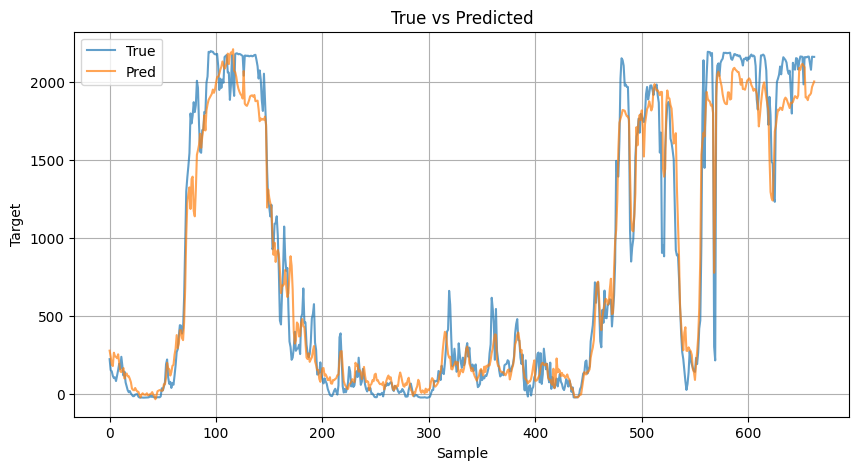

In [20]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred_val, weights = model(X_val_t, E_val_t)

y_true = y_val_t.cpu().numpy().flatten()
y_pred = y_pred_val.cpu().numpy().flatten()

plt.figure(figsize=(10, 5))
plt.plot(y_true, label="True", alpha=0.7)
plt.plot(y_pred, label="Pred", alpha=0.7)
plt.legend()
plt.title("True vs Predicted")
plt.xlabel("Sample")
plt.ylabel("Target")
plt.grid()
plt.show()

In [21]:
def mae_relative(y_true, y_pred):
    # MAE = Mean Average Error
    mae = np.mean(np.abs(y_pred - y_true))
    mean_target = np.mean(y_true)
    return 100 * mae / mean_target

mae_rel = mae_relative(y_true, y_pred)
mae = np.mean(np.abs(y_pred - y_true))

In [22]:

print(f"MAE: {mae}")
print(f"MAE Relative: {mae_rel}%")

MAE: 123.36383819580078
MAE Relative: 14.932557106018066%


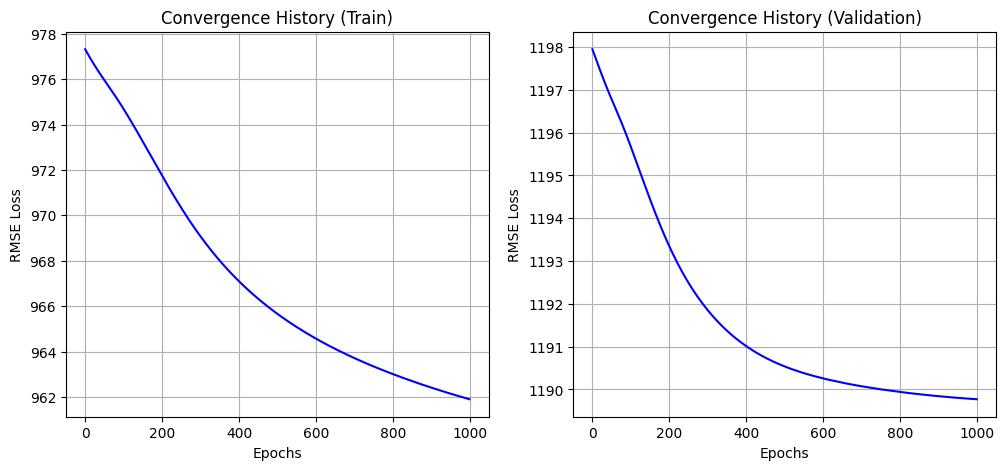

In [23]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12, 5))

# Plot 1: Learning Curve
plt.subplot(1, 2, 1)
plt.plot(history_train_loss, color='blue', label='Train Loss')
plt.title("Convergence History (Train)")
plt.xlabel("Epochs")
plt.ylabel("RMSE Loss")
plt.grid(True)

# Plot 2: Validation Curve
plt.subplot(1, 2, 2)
plt.plot(history_val_loss, color='blue', label='Train Loss')
plt.title("Convergence History (Validation)")
plt.xlabel("Epochs")
plt.ylabel("RMSE Loss")
plt.grid(True)

# 2. Predictions vs. Experts

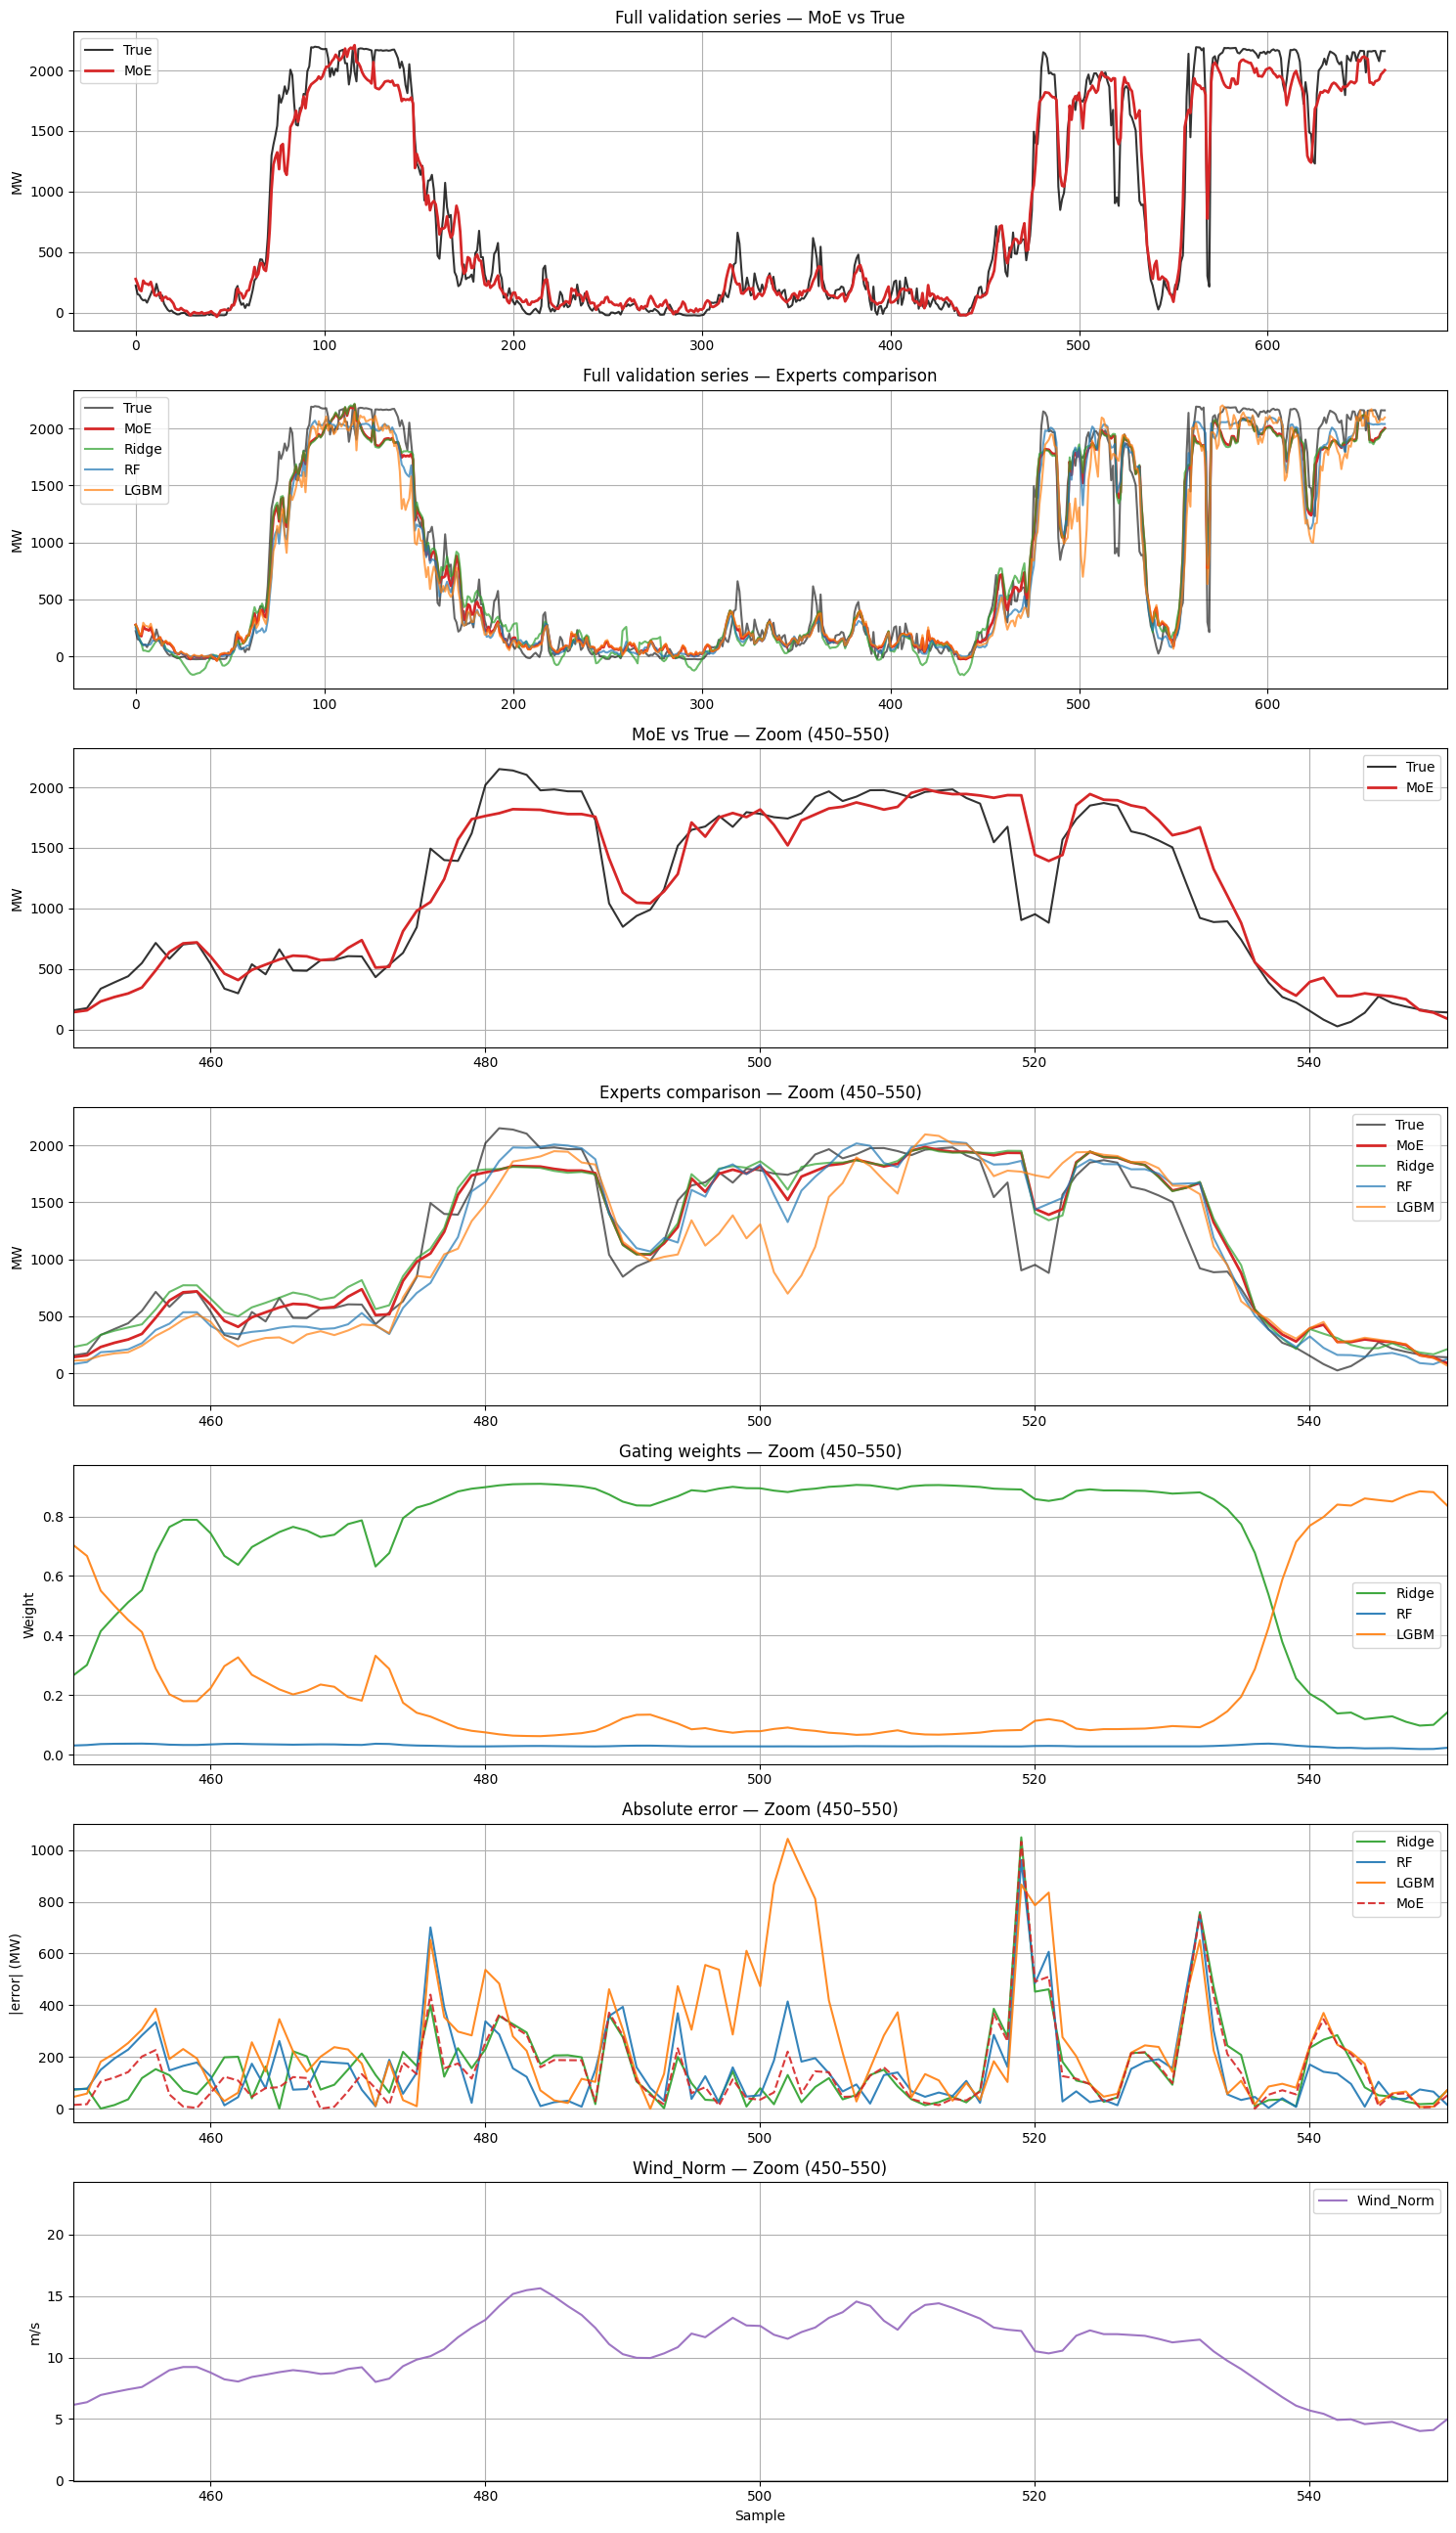

In [24]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()
with torch.no_grad():
    y_pred_val, w_val = model(X_val_t, E_val_t)

y_true = y_val_t.cpu().numpy().squeeze()
y_pred = y_pred_val.cpu().numpy().squeeze()
weights = w_val.cpu().numpy()

# experts
exp_1 = E_val.to_numpy()[:, 0]   # RIDGE
exp_2 = E_val.to_numpy()[:, 1]   # RF
exp_3 = E_val.to_numpy()[:, 2]   # LGBM

# zoom interval
start, end = 450, 550

# absolute errors
abs_err_moe   = np.abs(y_true - y_pred)
abs_err_ridge = np.abs(y_true - exp_1)
abs_err_rf    = np.abs(y_true - exp_2)
abs_err_lgbm  = np.abs(y_true - exp_3)

# contextual feature
wind_norm = X_val["Wind_Norm"].to_numpy()

# color map
colors = {
    "true": "black",
    "moe": "tab:red",
    "ridge": "tab:green",
    "rf": "tab:blue",
    "lgbm": "tab:orange",
    "wind": "tab:purple"
}

plt.figure(figsize=(15, 26))

# ----------------------------------
# 1 — True vs MoE
# ----------------------------------
plt.subplot(7, 1, 1)
plt.plot(y_true, label="True", color=colors["true"], alpha=0.8)
plt.plot(y_pred, label="MoE", color=colors["moe"], linewidth=2)
plt.legend()
plt.ylabel("MW")
plt.title("Full validation series — MoE vs True")
plt.grid()

# ----------------------------------
# 2 — All models
# ----------------------------------
plt.subplot(7, 1, 2)
plt.plot(y_true, label="True", color=colors["true"], alpha=0.6)
plt.plot(y_pred, label="MoE", color=colors["moe"], linewidth=2)
plt.plot(exp_1, label="Ridge", color=colors["ridge"], alpha=0.7)
plt.plot(exp_2, label="RF", color=colors["rf"], alpha=0.7)
plt.plot(exp_3, label="LGBM", color=colors["lgbm"], alpha=0.7)
plt.legend()
plt.ylabel("MW")
plt.title("Full validation series — Experts comparison")
plt.grid()

# ----------------------------------
# 3 — Zoom MoE
# ----------------------------------
plt.subplot(7, 1, 3)
plt.plot(y_true, label="True", color=colors["true"], alpha=0.8)
plt.plot(y_pred, label="MoE", color=colors["moe"], linewidth=2)
plt.legend()
plt.title(f"MoE vs True — Zoom ({start}–{end})")
plt.xlim((start, end))
plt.ylabel("MW")
plt.grid()

# ----------------------------------
# 4 — Zoom all models
# ----------------------------------
plt.subplot(7, 1, 4)
plt.plot(y_true, label="True", color=colors["true"], alpha=0.6)
plt.plot(y_pred, label="MoE", color=colors["moe"], linewidth=2)
plt.plot(exp_1, label="Ridge", color=colors["ridge"], alpha=0.7)
plt.plot(exp_2, label="RF", color=colors["rf"], alpha=0.7)
plt.plot(exp_3, label="LGBM", color=colors["lgbm"], alpha=0.7)
plt.legend()
plt.title(f"Experts comparison — Zoom ({start}–{end})")
plt.xlim((start, end))
plt.ylabel("MW")
plt.grid()

# ----------------------------------
# 5 — Weights
# ----------------------------------
plt.subplot(7, 1, 5)
plt.plot(weights[:, 0], label="Ridge", color=colors["ridge"], alpha=0.9)
plt.plot(weights[:, 1], label="RF", color=colors["rf"], alpha=0.9)
plt.plot(weights[:, 2], label="LGBM", color=colors["lgbm"], alpha=0.9)
plt.legend()
plt.title(f"Gating weights — Zoom ({start}–{end})")
plt.xlim((start, end))
plt.ylabel("Weight")
plt.grid()

# ----------------------------------
# 6 — Absolute errors
# ----------------------------------
plt.subplot(7, 1, 6)
plt.plot(abs_err_ridge, label="Ridge", color=colors["ridge"], alpha=0.9)
plt.plot(abs_err_rf, label="RF", color=colors["rf"], alpha=0.9)
plt.plot(abs_err_lgbm, label="LGBM", color=colors["lgbm"], alpha=0.9)
plt.plot(abs_err_moe, label="MoE", color=colors["moe"], alpha=0.9, linestyle="dashed")
plt.legend()
plt.title(f"Absolute error — Zoom ({start}–{end})")
plt.xlim((start, end))
plt.ylabel("|error| (MW)")
plt.grid()

# ----------------------------------
# 7 — Wind_Norm
# ----------------------------------
plt.subplot(7, 1, 7)
plt.plot(wind_norm, label="Wind_Norm", color=colors["wind"], alpha=0.9)
plt.legend()
plt.title(f"Wind_Norm — Zoom ({start}–{end})")
plt.xlim((start, end))
plt.xlabel("Sample")
plt.ylabel("m/s")
plt.grid()

plt.tight_layout()
plt.show()

In [25]:
start, end = 400, 600

err_moe  = np.abs(y_true - y_pred.squeeze())
err_rf   = np.abs(y_true - exp_1)
err_lgbm = np.abs(y_true - exp_2)
err_enet = np.abs(y_true - exp_3)


print(y_true.shape)
print(y_pred.squeeze().shape)

(663,)
(663,)


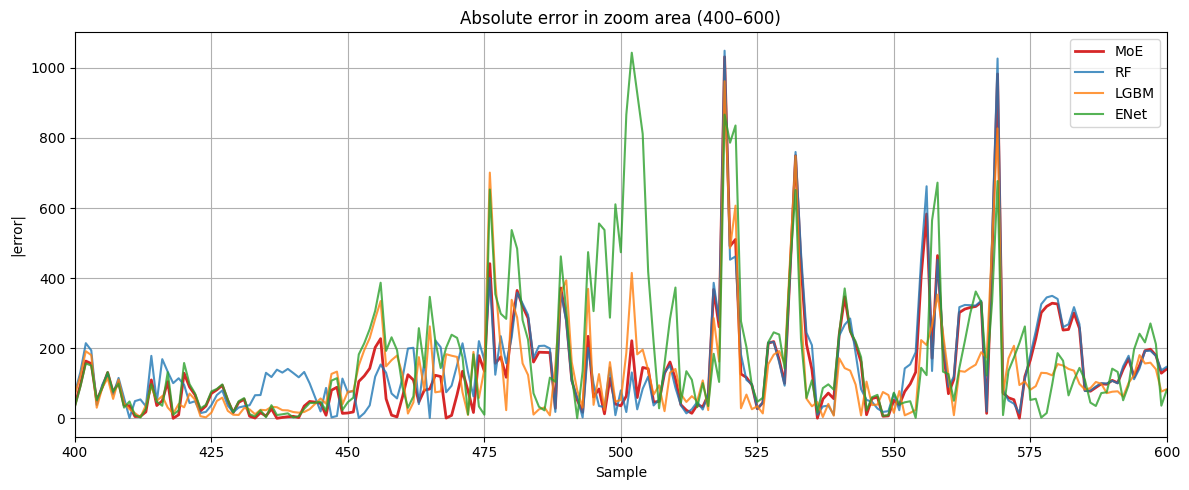

In [26]:

plt.figure(figsize=(12, 5))
plt.plot(err_moe,  label="MoE",  color="tab:red",    linewidth=2)
plt.plot(err_rf,   label="RF",   color="tab:blue",   alpha=0.8)
plt.plot(err_lgbm, label="LGBM", color="tab:orange", alpha=0.8)
plt.plot(err_enet, label="ENet", color="tab:green",  alpha=0.8)

plt.title("Absolute error in zoom area (400–600)")
plt.xlabel("Sample")
plt.ylabel("|error|")
plt.legend()
plt.grid()
plt.xlim((start, end))
plt.tight_layout()
plt.show()